In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
SEQ_LEN = 15
BATCH_SIZE = 2
NUM_EPOCHS = 15
LR = 1e-4

In [3]:
DATASET_PATH = "/mnt/d/deepfake/tf-gpu-env/complete_project/temporal_faces"

real_videos = glob.glob(os.path.join(DATASET_PATH, "real", "*"))
fake_videos = glob.glob(os.path.join(DATASET_PATH, "fake", "*"))

videos = real_videos + fake_videos
labels = [0]*len(real_videos) + [1]*len(fake_videos)

In [4]:
train_videos, val_videos, train_labels, val_labels = train_test_split(
    videos,
    labels,
    test_size=0.15,
    stratify=labels,
    random_state=42
)

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
class DeepfakeDataset(Dataset):

    def __init__(self, video_paths, labels, transform=None):
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):

        video_dir = self.video_paths[idx]
        label = self.labels[idx]

        frames = sorted(glob.glob(os.path.join(video_dir,"*.jpg")))

        imgs = []

        for f in frames[:15]:

            img = Image.open(f).convert("RGB")

            if self.transform:
                img = self.transform(img)

            imgs.append(img)

        imgs = torch.stack(imgs)

        return imgs, torch.tensor(label).float()

In [17]:
train_dataset = DeepfakeDataset(train_videos, train_labels, transform)
val_dataset = DeepfakeDataset(val_videos, val_labels, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [18]:
class DeepfakeDataset(Dataset):

    def __init__(self, video_paths, labels, transform=None, seq_len=15):
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform
        self.seq_len = seq_len

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):

        video_dir = self.video_paths[idx]
        label = self.labels[idx]

        frames = sorted(glob.glob(os.path.join(video_dir,"*.jpg")))

        imgs = []

        # If frames are fewer than seq_len → repeat last frame
        if len(frames) < self.seq_len:
            frames = frames + [frames[-1]]*(self.seq_len-len(frames))

        # If frames are more → sample
        frames = frames[:self.seq_len]

        for f in frames:

            img = Image.open(f).convert("RGB")

            if self.transform:
                img = self.transform(img)

            imgs.append(img)

        imgs = torch.stack(imgs)

        return imgs, torch.tensor(label).float()

In [19]:
model = DeepfakeModel().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

In [20]:
def train_epoch(model,loader):

    model.train()

    losses = []

    for x,y in tqdm(loader):

        x = x.to(DEVICE)
        y = y.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out,y)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)

In [21]:
def validate(model,loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for x,y in loader:

            x = x.to(DEVICE)

            out = model(x)

            prob = torch.sigmoid(out).cpu().numpy()

            preds.extend(prob)
            targets.extend(y.numpy())

    auc = roc_auc_score(targets,preds)

    pred_label = (np.array(preds)>0.5).astype(int)

    acc = accuracy_score(targets,pred_label)

    return auc,acc

In [22]:
for epoch in range(NUM_EPOCHS):

    train_loss = train_epoch(model,train_loader)

    val_auc,val_acc = validate(model,val_loader)

    print(f"Epoch {epoch+1}")

    print("Train Loss:",train_loss)

    print("Val AUC:",val_auc)

    print("Val ACC:",val_acc)

100%|█████████████████████████████████████████████████████████████████████████████████| 672/672 [02:04<00:00,  5.39it/s]


Epoch 1
Train Loss: 0.5921300400957643
Val AUC: 0.8478849166785358
Val ACC: 0.7637130801687764


100%|█████████████████████████████████████████████████████████████████████████████████| 672/672 [02:07<00:00,  5.28it/s]


Epoch 2
Train Loss: 0.399243280255524
Val AUC: 0.9283577837914827
Val ACC: 0.8185654008438819


100%|█████████████████████████████████████████████████████████████████████████████████| 672/672 [02:11<00:00,  5.12it/s]


...

Epoch 13
Train Loss: 0.0289048158537558
Val AUC: 0.9376157242558041
Val ACC: 0.8354430379746836


100%|█████████████████████████████████████████████████████████████████████████████████| 672/672 [02:04<00:00,  5.40it/s]


Epoch 14
Train Loss: 0.032048673291510135
Val AUC: 0.9342686227033187
Val ACC: 0.8481012658227848


100%|█████████████████████████████████████████████████████████████████████████████████| 672/672 [02:04<00:00,  5.41it/s]


Epoch 15
Train Loss: 0.01070024476461012
Val AUC: 0.9195271328870531
Val ACC: 0.7974683544303798


In [23]:
torch.save(model.state_dict(),"/mnt/d/deepfake/tf-gpu-env/complete_project/models/deepfake_model_temporal.pth")

In [24]:
model.eval()

DeepfakeModel(
  (cnn): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv

In [25]:
test_dataset = DeepfakeDataset(val_videos, val_labels, transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

In [26]:
all_preds = []
all_labels = []

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(DEVICE)

        out = model(x)

        probs = torch.sigmoid(out).cpu().numpy()

        all_preds.extend(probs)
        all_labels.extend(y.numpy())

In [27]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import numpy as np

In [28]:
pred_labels = (np.array(all_preds) > 0.5).astype(int)

acc = accuracy_score(all_labels, pred_labels)

auc = roc_auc_score(all_labels, all_preds)

cm = confusion_matrix(all_labels, pred_labels)

print("Test Accuracy:", acc)

print("Test AUC:", auc)

print("Confusion Matrix:")
print(cm)

Test Accuracy: 0.7974683544303798
Test AUC: 0.9195271328870531
Confusion Matrix:
[[ 83  36]
 [ 12 106]]


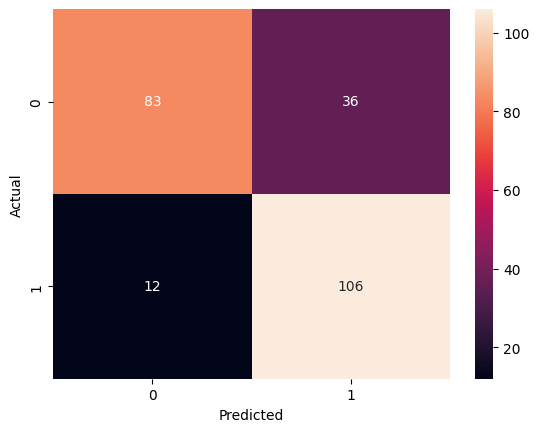

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
import cv2
import torch
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN

In [52]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [70]:
model = DeepfakeModel().to(DEVICE)

model.load_state_dict(torch.load("/mnt/d/deepfake/tf-gpu-env/complete_project/models/deepfake_model_temporal.pth", map_location=DEVICE))

model.eval()

DeepfakeModel(
  (cnn): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv

In [71]:
mtcnn = MTCNN(
    image_size=160,
    margin=20,
    device=DEVICE
)

In [72]:
def extract_frames(video_path, num_frames=60):

    cap = cv2.VideoCapture(video_path)

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    interval = max(total // num_frames, 1)

    frames = []
    count = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        if count % interval == 0:

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            frame = Image.fromarray(frame)

            frames.append(frame)

        count += 1

        if len(frames) == num_frames:
            break

    cap.release()

    return frames

In [73]:
def extract_faces(frames):

    faces = []

    for frame in frames:

        face = mtcnn(frame)

        if face is not None:
            faces.append(face)

    return faces

In [74]:
def build_sequences(faces, seq_len=15):

    sequences = []

    if len(faces) < seq_len:
        return None

    for i in range(0, len(faces) - seq_len + 1, seq_len):

        seq = faces[i:i+seq_len]

        seq = torch.stack(seq)

        seq = seq.unsqueeze(0)

        sequences.append(seq)

    return sequences

In [89]:
def predict_video(video_path):

    frames = extract_frames(video_path)

    print("Frames extracted:", len(frames))

    faces = extract_faces(frames)

    print("Faces detected:", len(faces))

    if faces is None or len(faces) < 15:
        return "Not enough faces detected"

    sequences = build_sequences(faces)

    print("Total sequences:", len(sequences))

    probs = []

    for seq in sequences:

        print("Sequence shape:", seq.shape)

        seq = seq.to(DEVICE)

        with torch.no_grad():

            out = model(seq)

            prob = torch.sigmoid(out).item()

        print("Sequence prob:", prob)

        probs.append(prob)

    final_prob = np.mean(probs)

    print("Final probability:", final_prob)

    if final_prob > 0.5:
        label = "FAKE"
    else:
        label = "REAL"

    return label, final_prob

In [90]:
video_path = "/mnt/d/deepfake/deepfake-env/FF++/real/06__kitchen_still.mp4"

result = predict_video(video_path)

print(result)

Frames extracted: 60
Faces detected: 60
Total sequences: 4
Sequence shape: torch.Size([1, 15, 3, 160, 160])
Sequence prob: 0.8903185129165649
Sequence shape: torch.Size([1, 15, 3, 160, 160])
Sequence prob: 0.931085467338562
Sequence shape: torch.Size([1, 15, 3, 160, 160])
Sequence prob: 0.90997713804245
Sequence shape: torch.Size([1, 15, 3, 160, 160])
Sequence prob: 0.90348219871521
Final probability: 0.9087158292531967
('FAKE', 0.9087158292531967)


In [69]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [87]:
print(next(model.parameters()).mean())

tensor(0.0006, device='cuda:0', grad_fn=<MeanBackward0>)


In [88]:
print(sequence.shape)

NameError: name 'sequence' is not defined